In [1]:
!pip install deepxde torch numpy matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [ ]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# --- Config ---
ALPHA      = 1.0
T_MAX      = 0.01
N_DOMAIN   = 10000
N_BOUNDARY = 800
N_INITIAL  = 500
W_PDE = 1
W_BC  = 10
W_IC  = 10
T_EVAL = [0.001, 0.005, 0.010]

# Fourier feature config
# σ=[1,3,5]: low captures coarse mode, mid+high capture fine sin(5πx) mode
# Reduced from [1,5,20] — σ=20 caused explosive PDE loss at init
SIGMA_BANDS = [1, 3, 5]
M_FREQ      = 32           # random frequencies per band
# Total Fourier features: 3 × 2 × 32 = 192

print(f"Backend: {dde.backend.backend_name}")
print(f"T_MAX={T_MAX}")
print(f"Fourier features: {len(SIGMA_BANDS)} bands × 2 × {M_FREQ} = {len(SIGMA_BANDS)*2*M_FREQ}")
print("Config loaded.")

In [3]:
def T_exact(x, y, t):
    """
    Two-mode analytical solution:
      mode 1 (low freq):  sin(πx)sin(πy) · exp(−2π²t)
      mode 2 (high freq): 0.3·sin(5πx)sin(5πy) · exp(−50π²t)
    """
    low  = np.sin(np.pi * x) * np.sin(np.pi * y) * np.exp(-2  * np.pi**2 * ALPHA * t)
    high = 0.3 * np.sin(5 * np.pi * x) * np.sin(5 * np.pi * y) * np.exp(-50 * np.pi**2 * ALPHA * t)
    return low + high

# Sanity checks
# 1. At t=0, T_exact should equal the IC
val = T_exact(np.array([0.5]), np.array([0.1]), 0.0)
ic  = np.sin(np.pi*0.5)*np.sin(np.pi*0.1) + 0.3*np.sin(5*np.pi*0.5)*np.sin(5*np.pi*0.1)
assert np.isclose(val[0], ic), f"IC mismatch: {val[0]} vs {ic}"
print(f"IC sanity check passed: T_exact(0.5, 0.1, 0) = {val[0]:.6f}")

# 2. Show high-freq mode amplitude at eval times
print("\nHigh-freq mode amplitude at eval times:")
for t in T_EVAL:
    amp = 0.3 * np.exp(-50 * np.pi**2 * ALPHA * t)
    print(f"  t={t:.3f}: {amp:.4f}")

IC sanity check passed: T_exact(0.5, 0.1, 0) = 0.609017

High-freq mode amplitude at eval times:
  t=0.001: 0.1831
  t=0.005: 0.0254
  t=0.010: 0.0022


In [4]:
geom       = dde.geometry.Rectangle(xmin=[0, 0], xmax=[1, 1])
timedomain = dde.geometry.TimeDomain(0, T_MAX)
geomtime   = dde.geometry.GeometryXTime(geom, timedomain)

print(f"Domain: [0,1]² × [0, {T_MAX}]")
print("GeometryXTime created successfully.")

Domain: [0,1]² × [0, 0.01]
GeometryXTime created successfully.


In [5]:
def pde(x, u):
    """
    Residual: ∂u/∂t − α(∂²u/∂x² + ∂²u/∂y²) = 0
    x[:,0]=x_coord, x[:,1]=y_coord, x[:,2]=t
    """
    u_t  = dde.grad.jacobian(u, x, i=0, j=2)
    u_xx = dde.grad.hessian(u, x, component=0, i=0, j=0)
    u_yy = dde.grad.hessian(u, x, component=0, i=1, j=1)
    return u_t - ALPHA * (u_xx + u_yy)

print("PDE residual function defined.")

PDE residual function defined.


In [6]:
# Dirichlet BC: T = 0 on all boundaries
bc = dde.icbc.DirichletBC(
    geomtime,
    func=lambda x: np.zeros((len(x), 1)),
    on_boundary=lambda x, on_boundary: on_boundary,
)

# IC: T(x,y,0) = sin(πx)sin(πy) + 0.3·sin(5πx)sin(5πy)
def ic_func(x):
    low  = np.sin(np.pi * x[:, 0:1]) * np.sin(np.pi * x[:, 1:2])
    high = 0.3 * np.sin(5 * np.pi * x[:, 0:1]) * np.sin(5 * np.pi * x[:, 1:2])
    return low + high

ic = dde.icbc.IC(
    geomtime,
    func=ic_func,
    on_initial=lambda x, on_initial: on_initial,
)

print("BC (Dirichlet, T=0) defined.")
print("IC (two-mode sinusoidal) defined.")

BC (Dirichlet, T=0) defined.
IC (two-mode sinusoidal) defined.


In [7]:
def solution_func(x):
    """Analytical solution for DeepXDE test metric."""
    low  = (np.sin(np.pi * x[:, 0:1]) * np.sin(np.pi * x[:, 1:2])
            * np.exp(-2 * np.pi**2 * ALPHA * x[:, 2:3]))
    high = (0.3 * np.sin(5 * np.pi * x[:, 0:1]) * np.sin(5 * np.pi * x[:, 1:2])
            * np.exp(-50 * np.pi**2 * ALPHA * x[:, 2:3]))
    return low + high

data = dde.data.TimePDE(
    geometryxtime=geomtime,
    pde=pde,
    ic_bcs=[bc, ic],
    num_domain=N_DOMAIN,
    num_boundary=N_BOUNDARY,
    num_initial=N_INITIAL,
    train_distribution="LHS",
    solution=solution_func,
    num_test=1000,
)

print("Dataset assembled:")
print(f"  Domain : {N_DOMAIN} pts (LHS)")
print(f"  Boundary: {N_BOUNDARY} pts")
print(f"  IC      : {N_INITIAL} pts")
print(f"  Test    : 1000 pts vs analytical solution")

Dataset assembled:
  Domain : 10000 pts (LHS)
  Boundary: 800 pts
  IC      : 500 pts
  Test    : 1000 pts vs analytical solution


In [ ]:
class MultiscaleFourierNet(dde.nn.NN):
    """
    Fourier feature PINN network.
    Inputs are normalized to [-1,1] before encoding to prevent large-σ
    bands from producing explosive initial PDE residuals.
    """
    def __init__(self, sigma_bands, m_freq, mlp_hidden, t_max, activation="tanh"):
        super().__init__()
        self.sigma_bands = sigma_bands
        self.t_max = t_max
        n_fourier = len(sigma_bands) * 2 * m_freq

        # Frozen random frequency matrices, one per band
        for i, sigma in enumerate(sigma_bands):
            B = torch.randn(3, m_freq) * sigma
            self.register_parameter(
                f"B_{i}", nn.Parameter(B, requires_grad=False)
            )

        # MLP: n_fourier → hidden → ... → 1
        sizes = [n_fourier] + mlp_hidden + [1]
        layers = []
        act = nn.Tanh() if activation == "tanh" else nn.ReLU()
        for in_sz, out_sz in zip(sizes[:-2], sizes[1:-1]):
            layers += [nn.Linear(in_sz, out_sz), act]
        layers.append(nn.Linear(sizes[-2], sizes[-1]))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # Normalize inputs to [-1, 1] before Fourier encoding
        # x[:,0], x[:,1] in [0,1]  ->  2*x - 1
        # x[:,2]          in [0, t_max] -> 2*x/t_max - 1
        x_norm = torch.empty_like(x)
        x_norm[:, 0:2] = 2.0 * x[:, 0:2] - 1.0
        x_norm[:, 2:3] = 2.0 * x[:, 2:3] / self.t_max - 1.0

        features = []
        for i in range(len(self.sigma_bands)):
            B = getattr(self, f"B_{i}")
            proj = x_norm @ B
            features.append(torch.sin(proj))
            features.append(torch.cos(proj))
        z = torch.cat(features, dim=-1)
        return self.mlp(z)

    def output_transform(self, x, y):
        return y

# Quick shape test
_net_test = MultiscaleFourierNet(SIGMA_BANDS, M_FREQ, [64, 64, 64], T_MAX)
_x_test   = torch.rand(10, 3) * torch.tensor([1.0, 1.0, T_MAX])
_out      = _net_test(_x_test)
assert _out.shape == (10, 1), f"Expected (10,1), got {_out.shape}"
print(f"MultiscaleFourierNet shape test passed: (10,3) → {_out.shape}")

total_params = sum(p.numel() for p in _net_test.parameters())
trainable    = sum(p.numel() for p in _net_test.parameters() if p.requires_grad)
print(f"Total parameters : {total_params:,}")
print(f"Trainable params : {trainable:,}  (frozen Fourier matrices excluded)")
del _net_test, _x_test, _out

In [ ]:
fourier_net   = MultiscaleFourierNet(SIGMA_BANDS, M_FREQ, [64, 64, 64], T_MAX)
fourier_model = dde.Model(data, fourier_net)

# --- Adam phase ---
fourier_model.compile("adam", lr=1e-3, loss_weights=[W_PDE, W_BC, W_IC])
losshistory, train_state = fourier_model.train(iterations=10000)

dde.utils.plot_loss_history(losshistory)
plt.title("Fourier PINN — Adam training loss")
plt.tight_layout()
plt.show()

# --- L-BFGS phase ---
fourier_model.compile("L-BFGS", loss_weights=[W_PDE, W_BC, W_IC])
losshistory, train_state = fourier_model.train()

dde.utils.plot_loss_history(losshistory)
plt.title("Fourier PINN — L-BFGS fine-tuning loss")
plt.tight_layout()
plt.show()

print("Fourier PINN training complete.")

In [ ]:
# Plain FNN baseline — same architecture as phase 1 (5 hidden layers × 32 neurons)
# Trained from scratch on the same multi-freq IC for fair comparison
baseline_net   = dde.nn.FNN([3] + [32] * 5 + [1], "tanh", "Glorot normal")
baseline_model = dde.Model(data, baseline_net)

# --- Adam phase ---
baseline_model.compile("adam", lr=1e-3, loss_weights=[W_PDE, W_BC, W_IC])
losshistory_b, _ = baseline_model.train(iterations=10000)

dde.utils.plot_loss_history(losshistory_b)
plt.title("Baseline FNN — Adam training loss")
plt.tight_layout()
plt.show()

# --- L-BFGS phase ---
baseline_model.compile("L-BFGS", loss_weights=[W_PDE, W_BC, W_IC])
losshistory_b, _ = baseline_model.train()

dde.utils.plot_loss_history(losshistory_b)
plt.title("Baseline FNN — L-BFGS fine-tuning loss")
plt.tight_layout()
plt.show()

print("Baseline FNN training complete.")

     t |   Fourier L2 |  Baseline L2 |  Improvement
----------------------------------------------------


 0.001 |     1.70e-01 |     1.35e-01 |         0.8×


 0.005 |     3.52e-02 |     3.10e-02 |         0.9×
 0.010 |     2.92e-02 |     1.94e-02 |         0.7×


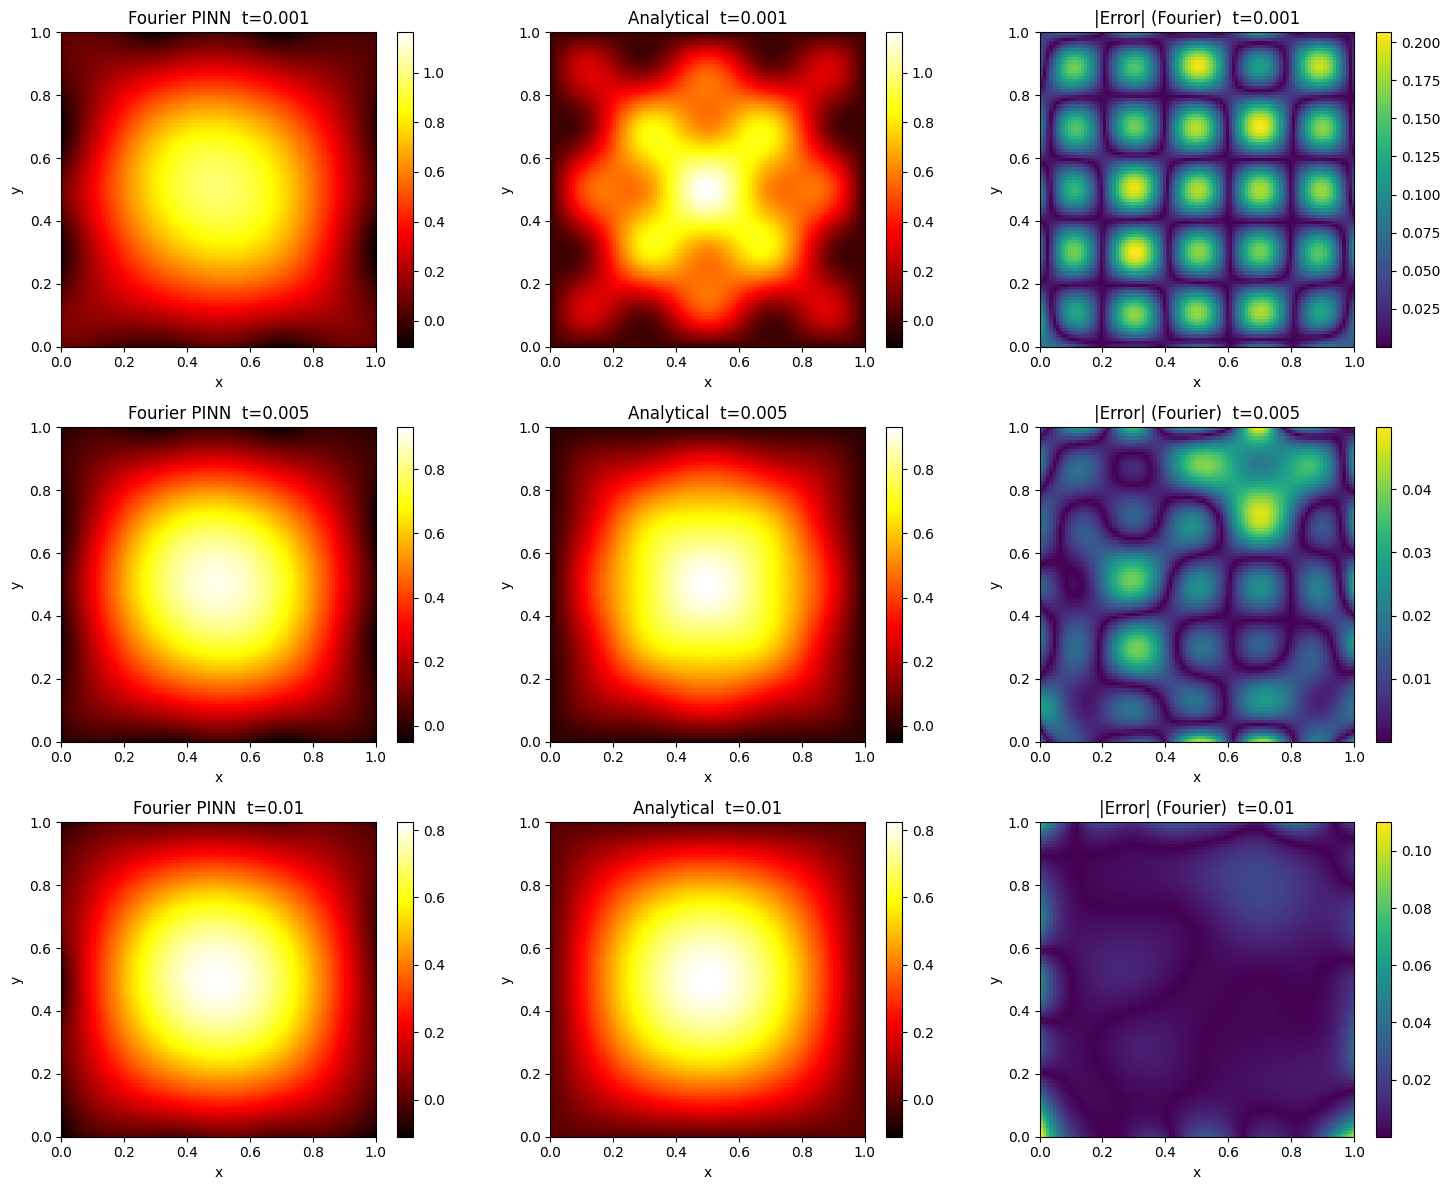

Evaluation complete. Figure saved to pinn_2d_fourier_results.png


In [11]:
x_lin = np.linspace(0, 1, 100)
y_lin = np.linspace(0, 1, 100)
X, Y  = np.meshgrid(x_lin, y_lin)

print(f"{'t':>6} | {'Fourier L2':>12} | {'Baseline L2':>12} | {'Improvement':>12}")
print("-" * 52)

fig, axes = plt.subplots(len(T_EVAL), 3, figsize=(15, 4 * len(T_EVAL)))

for row, t_val in enumerate(T_EVAL):
    t_arr = np.full(X.shape, t_val)
    pts   = np.column_stack([X.ravel(), Y.ravel(), t_arr.ravel()])

    T_fourier  = fourier_model.predict(pts).reshape(100, 100)
    T_baseline = baseline_model.predict(pts).reshape(100, 100)
    T_true     = T_exact(X, Y, t_val)

    l2_fourier  = np.linalg.norm(T_fourier  - T_true) / np.linalg.norm(T_true)
    l2_baseline = np.linalg.norm(T_baseline - T_true) / np.linalg.norm(T_true)
    improvement = l2_baseline / l2_fourier  # >1 means Fourier is better

    print(f"{t_val:>6.3f} | {l2_fourier:>12.2e} | {l2_baseline:>12.2e} | {improvement:>11.1f}×")

    error = np.abs(T_fourier - T_true)
    vmin  = min(T_fourier.min(), T_true.min())
    vmax  = max(T_fourier.max(), T_true.max())

    im0 = axes[row, 0].imshow(T_fourier, origin="lower", extent=[0,1,0,1],
                               vmin=vmin, vmax=vmax, cmap="hot")
    axes[row, 0].set_title(f"Fourier PINN  t={t_val}")
    axes[row, 0].set_xlabel("x"); axes[row, 0].set_ylabel("y")
    plt.colorbar(im0, ax=axes[row, 0])

    im1 = axes[row, 1].imshow(T_true, origin="lower", extent=[0,1,0,1],
                               vmin=vmin, vmax=vmax, cmap="hot")
    axes[row, 1].set_title(f"Analytical  t={t_val}")
    axes[row, 1].set_xlabel("x"); axes[row, 1].set_ylabel("y")
    plt.colorbar(im1, ax=axes[row, 1])

    im2 = axes[row, 2].imshow(error, origin="lower", extent=[0,1,0,1],
                               cmap="viridis")
    axes[row, 2].set_title(f"|Error| (Fourier)  t={t_val}")
    axes[row, 2].set_xlabel("x"); axes[row, 2].set_ylabel("y")
    plt.colorbar(im2, ax=axes[row, 2])

plt.tight_layout()
plt.savefig("pinn_2d_fourier_results.png", dpi=150)
plt.show()
print("Evaluation complete. Figure saved to pinn_2d_fourier_results.png")